# Regime Engine v2 — Calibration Q4

**Round 4** — apply concept-level aggregation to the market layer (mirroring Q2 on macro), add beta-adjusted relative returns for equity-style and sector-rotation signals, swap the broad commodity proxy to S&P GSCI.

Prior rounds: [Q1+Q2](regime_v2_calibration_q1q2.ipynb) (macro scale + concepts), [Q3](regime_v2_calibration_q3.ipynb) (market tanh, lower thresholds, hysteresis).

## Changes applied

1. **Market concept aggregation** in [`market_regime.py`](../../market_helper/regimes/methods/market_regime.py): added `MarketConceptSpec`, loader, and concept-aware `compute_market_axis_scores`. When concept blocks are present, signals → concept (within-weighted) → axis (concept-weighted), exposing `concept:{axis}:{name}` columns in the score frame. Empty `concepts` falls back to the old flat per-signal aggregation for legacy compat.

2. **Beta-adjusted relative return** transform: `r_num - β·r_den` where β is a 60-day EWMA rolling regression slope, clipped ±3. Applied to QQQ vs SPY, IWM vs SPY, XLY/XLP, XLI/XLU, XLK/XLU. Strips out market-beta exposure so the signal measures genuine regime preference rather than volatility ride. NOT applied to commodities, rates pricing, vol, or credit (those measure different latent states, not equity styles).

3. **S&P GSCI** added to data sources (`^SPGSCI`, alias `SPGSCI`) and used as the primary commodity-inflation member at 0.5 within-weight (oil 0.3, DBC 0.2). 10,670 daily observations from 1984.

4. **TLT/SPY (defensive_treasury_outperformance) dropped from growth axis** — was 0.73 correlated with broad equity momentum (literally `TLT - SPY`). Lives only in the risk overlay as `flight_to_quality` now.

## Concept structure (market layer)

```yaml
growth_concepts:
  broad_equity_momentum: {weight: 0.8, signals: {spy_momentum: 0.5, qqq_vs_spy_beta_adj: 0.3, iwm_vs_spy_beta_adj: 0.2}}
  cyclical_rotation:     {weight: 1.0, signals: {discretionary_vs_staples: 0.4, industrials_vs_utilities: 0.3, tech_vs_utilities: 0.3}}
  risk_appetite:         {weight: 0.8, signals: {credit_risk_appetite: 1.0}}
  commodity_demand:      {weight: 0.5, signals: {copper_momentum: 1.0}}

inflation_concepts:
  commodity_inflation:        {weight: 1.0, signals: {sp_gsci_momentum: 0.5, oil_momentum: 0.3, broad_commodity_momentum: 0.2}}
  inflation_pricing_proxy:    {weight: 1.0, signals: {tip_vs_nominal_treasury: 1.0}}
  gold_haven_inflation_proxy: {weight: 0.5, signals: {gold_momentum: 1.0}}

risk_concepts:
  volatility:        {weight: 1.0,  signals: {vix_level: 0.45, move_level: 0.30, equity_realized_vol: 0.25}}
  credit_stress:     {weight: 1.0,  signals: {credit_stress: 1.0}}
  flight_to_quality: {weight: 0.75, signals: {flight_to_quality: 1.0}}
```

### Pre-Q4 redundancy picture (motivation)

**Market-layer signal correlations before concept aggregation**

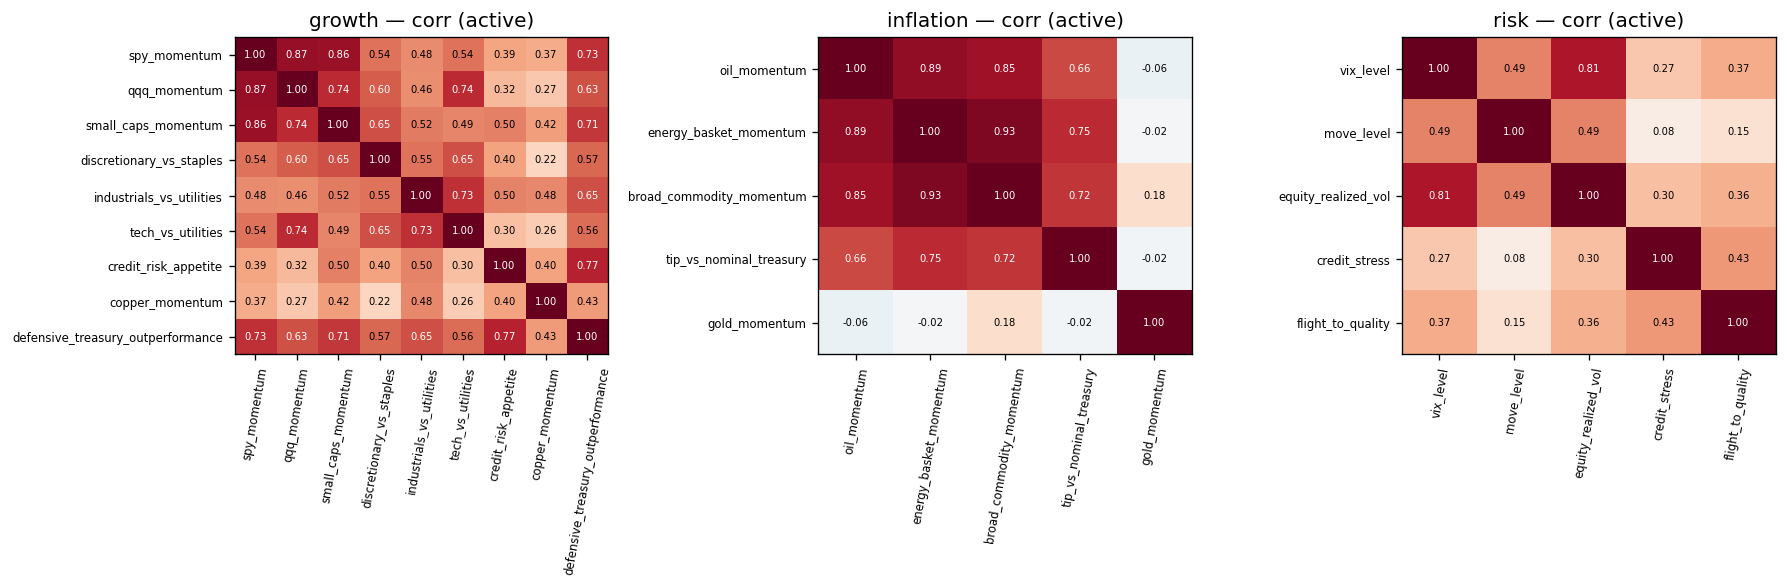

### Validation outputs (1–7)

**(1) Per-signal contribution stats — market layer (post-Q4)**

| signal | axis | transform | n_obs | mean | std | abs_p95 | min | max |
|---|---|---|---|---|---|---|---|---|
| copper_momentum | growth | return | 3654 | 0.008172464175438614 | 0.4329379650820988 | 0.7990686380211036 | -0.9051482536448664 | 0.9051482536448664 |
| credit_risk_appetite | growth | relative_return | 4853 | 0.0041884014140784204 | 0.4140965068074029 | 0.7850510409403331 | -0.9051482536448664 | 0.9051482536448664 |
| discretionary_vs_staples | growth | beta_adjusted_relative_return | 6875 | -0.0017565056095947573 | 0.4272859291455234 | 0.811533145702934 | -0.9051482536448664 | 0.9051482536448664 |
| industrials_vs_utilities | growth | beta_adjusted_relative_return | 6875 | 0.00027235425796861613 | 0.4232093102868865 | 0.7670566637167694 | -0.9051482536448664 | 0.9051482536448664 |
| iwm_vs_spy_beta_adj | growth | beta_adjusted_relative_return | 6649 | -0.012030537709169287 | 0.428503896276122 | 0.775070746981992 | -0.9051482536448664 | 0.9051482536448664 |
| qqq_vs_spy_beta_adj | growth | beta_adjusted_relative_return | 6875 | -0.019967094883288836 | 0.4137941674351196 | 0.766750797988231 | -0.9051482536448664 | 0.9051482536448664 |
| spy_momentum | growth | return | 6875 | -0.007550193240166004 | 0.4255795220044863 | 0.8102622971601229 | -0.9051482536448664 | 0.9051482536448664 |
| tech_vs_utilities | growth | beta_adjusted_relative_return | 6875 | 0.011209443944938599 | 0.42786275785723493 | 0.795276014440203 | -0.9051482536448664 | 0.9051482536448664 |
| broad_commodity_momentum | inflation | return | 5160 | 0.011540892704305434 | 0.438945431850085 | 0.8523117335423597 | -0.9051482536448664 | 0.9051482536448664 |
| gold_momentum | inflation | return | 5477 | 0.03623717265863102 | 0.44762834930727574 | 0.8052628372307559 | -0.9051482536448664 | 0.9051482536448664 |
| oil_momentum | inflation | return | 5115 | 0.021680741505965825 | 0.4338831540435312 | 0.8413113338810472 | -0.9051482536448664 | 0.9051482536448664 |
| sp_gsci_momentum | inflation | return | 6875 | 0.0013104227716021165 | 0.4295814313641954 | 0.8173244737753275 | -0.9051482536448664 | 0.9051482536448664 |
| tip_vs_nominal_treasury | inflation | relative_return | 5726 | -0.017564173433487547 | 0.4165292531827763 | 0.7893381288082657 | -0.9051482536448664 | 0.9051482536448664 |
| credit_stress | risk | relative_return | 4853 | -0.0041884014140784204 | 0.4140965068074029 | 0.7850510409403331 | -0.9051482536448664 | 0.9051482536448664 |
| equity_realized_vol | risk | realized_vol | 6875 | -0.057109482395692183 | 0.41676018553979444 | 0.8135789019519593 | -0.7523761684595022 | 0.9051482536448664 |
| flight_to_quality | risk | relative_return | 6121 | -0.01180437632331062 | 0.3970038838035873 | 0.7917111944488184 | -0.9051482536448664 | 0.9051482536448664 |
| move_level | risk | level | 6067 | -0.11849064840500075 | 0.5016177899845601 | 0.8486314269727248 | -0.9051482536448664 | 0.9051482536448664 |
| vix_level | risk | level | 6875 | -0.07210566356220872 | 0.437967005863181 | 0.83230830818672 | -0.7502251430084153 | 0.9051482536448664 |

**(2) Per-concept stats — market layer**

| axis | concept | weight | n_obs | mean | std | abs_p95 | min | max |
|---|---|---|---|---|---|---|---|---|
| growth | broad_equity_momentum | 0.8 | 6875 | -0.01334689387377712 | 0.27442132753641474 | 0.5392737747713904 | -0.8742582944997309 | 0.8261494132738396 |
| growth | commodity_demand | 0.5 | 3654 | 0.008172464175438614 | 0.4329379650820988 | 0.7990686380211036 | -0.9051482536448664 | 0.9051482536448664 |
| growth | cyclical_rotation | 1.0 | 6875 | 0.0027419372170342615 | 0.3644645071048823 | 0.7251492817832585 | -0.9051482536448664 | 0.8822670018579266 |
| growth | risk_appetite | 0.8 | 4853 | 0.0041884014140784204 | 0.4140965068074029 | 0.7850510409403331 | -0.9051482536448664 | 0.9051482536448664 |
| inflation | commodity_inflation | 1.0 | 6875 | 0.010306664027992218 | 0.42196942290469575 | 0.8092078221265326 | -0.9051482536448663 | 0.9051482536448663 |
| inflation | gold_haven_inflation_proxy | 0.5 | 5477 | 0.03623717265863102 | 0.44762834930727574 | 0.8052628372307559 | -0.9051482536448664 | 0.9051482536448664 |
| inflation | inflation_pricing_proxy | 1.0 | 5726 | -0.017564173433487547 | 0.4165292531827763 | 0.7893381288082657 | -0.9051482536448664 | 0.9051482536448664 |
| risk | credit_stress | 1.0 | 4853 | -0.0041884014140784204 | 0.4140965068074029 | 0.7850510409403331 | -0.9051482536448664 | 0.9051482536448664 |
| risk | flight_to_quality | 0.75 | 6121 | -0.01180437632331062 | 0.3970038838035873 | 0.7917111944488184 | -0.9051482536448664 | 0.9051482536448664 |
| risk | volatility | 1.0 | 6875 | -0.07596180614681845 | 0.3911647745582963 | 0.72734170861241 | -0.6651980363808957 | 0.9051482536448665 |

**Concept time series, post-Q4 (growth / inflation / risk)**

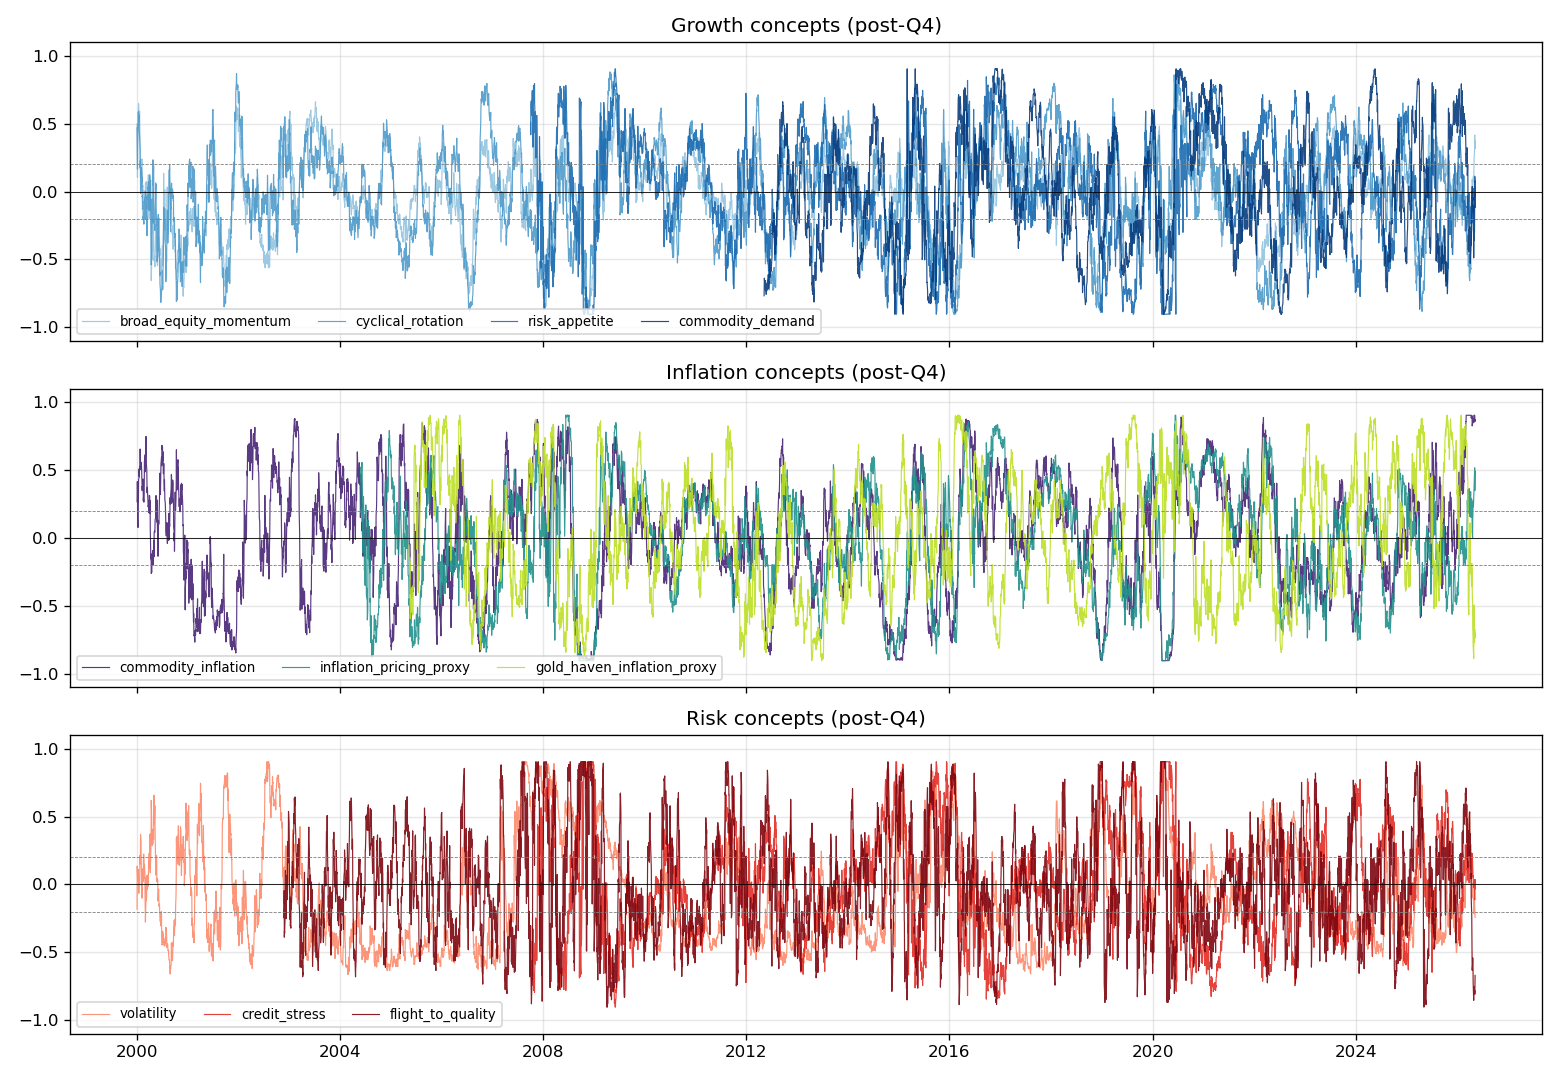

**(3) Per-axis distribution (macro vs market vs final)**

| axis | layer | n_obs | mean | std | abs_p95 | min | max |
|---|---|---|---|---|---|---|---|
| growth | macro | 8173 | -0.012869411480317582 | 0.3410252092646774 | 0.7718325111151476 | -0.9051482536448664 | 0.7719840740961453 |
| growth | market | 6875 | -0.005624300529730859 | 0.2924949830126471 | 0.565635780079 | -0.893906744709802 | 0.7834565764665987 |
| growth | final | 8180 | 0.004359237975012251 | 0.23465660987837866 | 0.4704999313697731 | -0.8820877773078784 | 0.7299337320557796 |
| inflation | macro | 8173 | -0.07413082642306527 | 0.31519021917582096 | 0.6034321690965776 | -0.7434457139752675 | 0.8320351898396091 |
| inflation | market | 6875 | 0.0073602508016103775 | 0.3442541976505234 | 0.6754315980625378 | -0.8990585266556526 | 0.8796676785425793 |
| inflation | final | 8180 | -0.021109249578008617 | 0.24946467152916454 | 0.4958024607098678 | -0.6666406997037824 | 0.6657368293742013 |

**Macro vs market vs final, post-Q4**

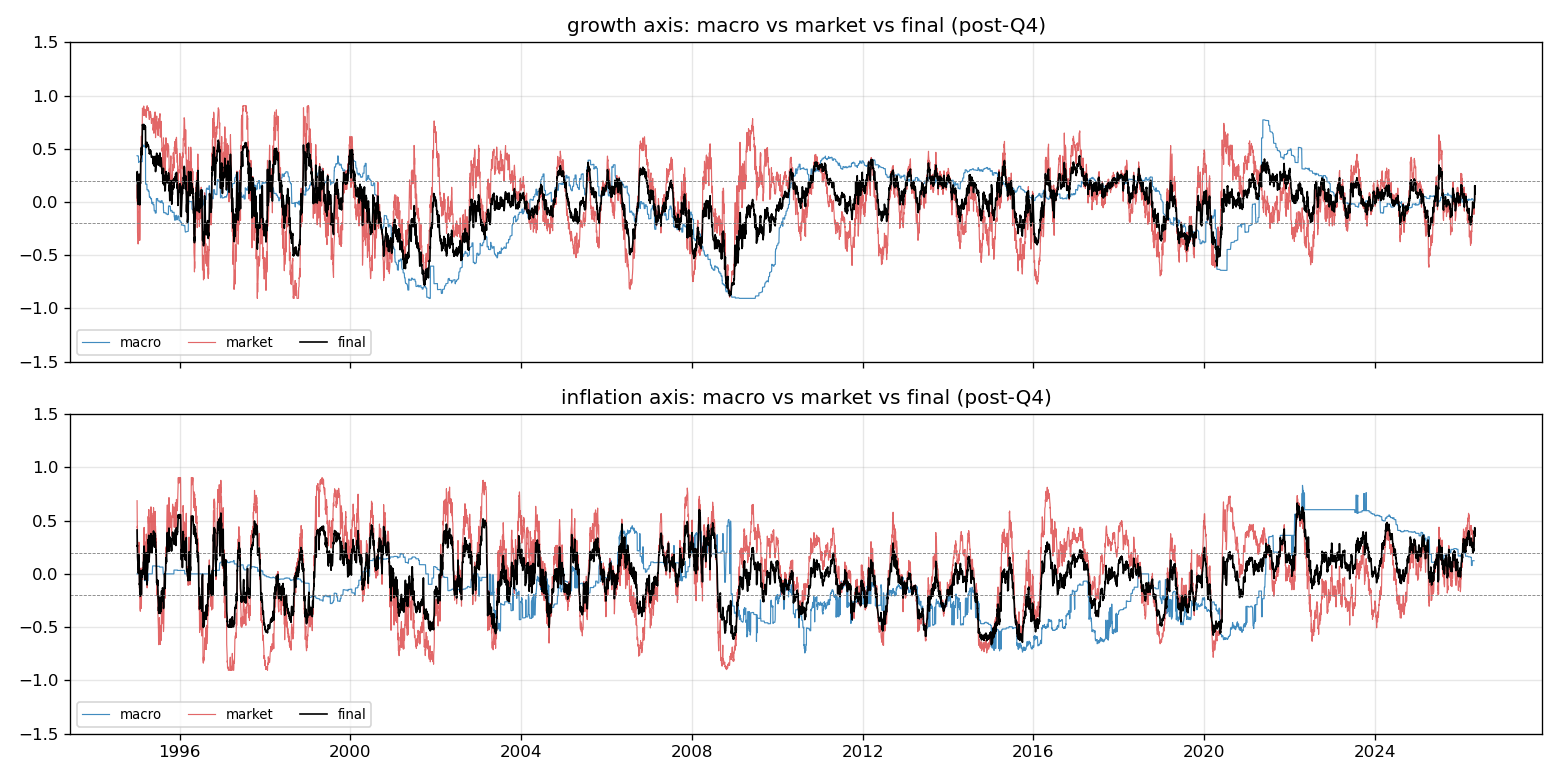

**(4) Anchor period regime summary**

| period | n | majority_regime | majority_share | stress_share | disagreement_share | macro_g | macro_i | market_g | market_i | final_g | final_i |
|---|---|---|---|---|---|---|---|---|---|---|---|
| 2008 GFC | 87 | Slowdown / Deflationary Slowdown + Stress Overlay | 0.6666666666666666 | 0.6666666666666666 | 0.5747126436781609 | -0.8195582520915953 | 0.131068809954316 | -0.5299876791394791 | -0.8113164311984178 | -0.6602944369679314 | -0.43436233473732433 |
| 2009-10 Recovery | 325 | Neutral/Mixed Growth / Neutral/Mixed Inflation | 0.6307692307692307 | 0.0 | 0.4707692307692308 | -0.47801908123895226 | -0.33391592372476425 | 0.27586988081075237 | 0.15440476840225015 | -0.06338015211161471 | -0.04092350844855563 |
| 2011 Euro / US downgrade | 131 | Neutral/Mixed Growth / Neutral/Mixed Inflation | 0.6183206106870229 | 0.0 | 0.24427480916030533 | 0.3441342287295577 | -0.22863999566885007 | -0.21505577918060004 | -0.12451841549323797 | 0.03657972437897091 | -0.16616704756348283 |
| 2014-16 Oil collapse | 413 | Neutral/Mixed Growth / Down Inflation | 0.6029055690072639 | 0.01694915254237288 | 0.24939467312348668 | 0.1661796770093792 | -0.5601652272010987 | -0.20528674007290953 | -0.22823945965154638 | -0.03812685238587964 | -0.3610097666713673 |
| 2017 Soft landing | 260 | Neutral/Mixed Growth / Neutral/Mixed Inflation | 0.4230769230769231 | 0.0 | 0.2423076923076923 | 0.17755576408950396 | -0.40243532439120416 | 0.19332829952561686 | 0.15500979412303478 | 0.18623065857936605 | -0.06796825328266078 |
| 2018 Q4 Selloff | 65 | Neutral/Mixed Growth / Down Inflation | 0.4307692307692308 | 0.07692307692307693 | 0.0 | 0.127707116284786 | -0.13441746608484248 | -0.35883391006293924 | -0.35527469663648764 | -0.13989044820646288 | -0.2669318044158296 |
| 2020 COVID shock | 53 | Slowdown / Deflationary Slowdown + Stress Overlay | 0.5849056603773585 | 0.6226415094339622 | 0.0 | -0.24231787796877058 | -0.3120158703907591 | -0.41149887065816104 | -0.5098438468124935 | -0.33536742394793534 | -0.4307126562437997 |
| 2020H2-21 Reopening | 392 | Neutral/Mixed Growth / Neutral/Mixed Inflation | 0.6275510204081632 | 0.0 | 0.3647959183673469 | 0.10833285834956832 | -0.14455013702975708 | 0.1873594925749686 | 0.2597307552349307 | 0.1517975071735385 | 0.09801839832905558 |
| 2022 Inflation / Tightening | 260 | Neutral/Mixed Growth / Neutral/Mixed Inflation | 0.6423076923076924 | 0.0 | 0.47307692307692306 | 0.31038787953135494 | 0.5720066752918467 | -0.17109018469843582 | -0.052445974016461276 | 0.045574944204970026 | 0.1973350857068619 |
| 2023-24 Disinflation | 413 | Neutral/Mixed Growth / Neutral/Mixed Inflation | 0.5205811138014528 | 0.0 | 0.27602905569007263 | -0.023866430509304783 | 0.5134606460096025 | 0.09126789759096338 | -0.05265212495490676 | 0.03945744994584271 | 0.17379298343089697 |
| 2025 Tariff shock (Apr) | 21 | Down Growth / Neutral/Mixed Inflation | 0.5238095238095238 | 0.23809523809523808 | 0.0 | 0.04367935605292626 | 0.2546972702275468 | -0.445912827153338 | -0.11965807321950526 | -0.225596344710519 | 0.03008406415931558 |
| 2026 YTD | 92 | Neutral/Mixed Growth / Up Inflation | 0.8043478260869565 | 0.0 | 0.0 | 0.017769405718111808 | 0.16209298794637397 | -0.04851928843628617 | 0.32342319733265296 | -0.016863275847359506 | 0.26588207744827547 |

**(5) Macro-vs-market disagreement share**

Overall: **19.9%**; recent 5y: **22.5%**. Disagreement years line up with real macro debates (2016 China devaluation: 50%, 2020 COVID: 49%, 2022 inflation: 47%, 2023 disinflation: 37%).

| year | share |
|---|---|
| 2012 | 0.17 |
| 2013 | 0.00 |
| 2014 | 0.14 |
| 2015 | 0.26 |
| 2016 | **0.50** |
| 2017 | 0.24 |
| 2018 | 0.10 |
| 2019 | 0.04 |
| 2020 | **0.49** |
| 2021 | 0.18 |
| 2022 | **0.47** |
| 2023 | **0.37** |
| 2024 | 0.25 |
| 2025 | 0.00 |
| 2026 | 0.00 |


**(6) Neutral fraction: 70.9%** (was 72.9% in Q3) — slight improvement.

Top labels:

| label | days |
|---|---|
| Neutral/Mixed Growth / Neutral/Mixed Inflation | 3245 |
| Goldilocks / Expansion | 1099 |
| Neutral/Mixed Growth / Down Inflation | 963 |
| Neutral/Mixed Growth / Up Inflation | 936 |
| Slowdown / Deflationary Slowdown | 491 |
| Down Growth / Neutral/Mixed Inflation | 369 |
| Reflation | 248 |
| Stagflation-like | 224 |
| Slowdown / Deflationary Slowdown + Stress Overlay | 190 |
| Down Growth / Neutral/Mixed Inflation + Stress Overlay | 108 |


**(7) Regime turnover**

315 transitions over 31.3 years → **10.05 flips/year** (was 9.25 in Q3). Median run: **16 bdays** (was 18). Roughly stable.

| stat | bdays |
|---|---|
| count | 316 |
| mean | 25.9 |
| 25% | 8 |
| 50% | 16 |
| 75% | 34 |
| 95% | 78 |
| max | 162 |


**Regime time-strip (post-Q4)**

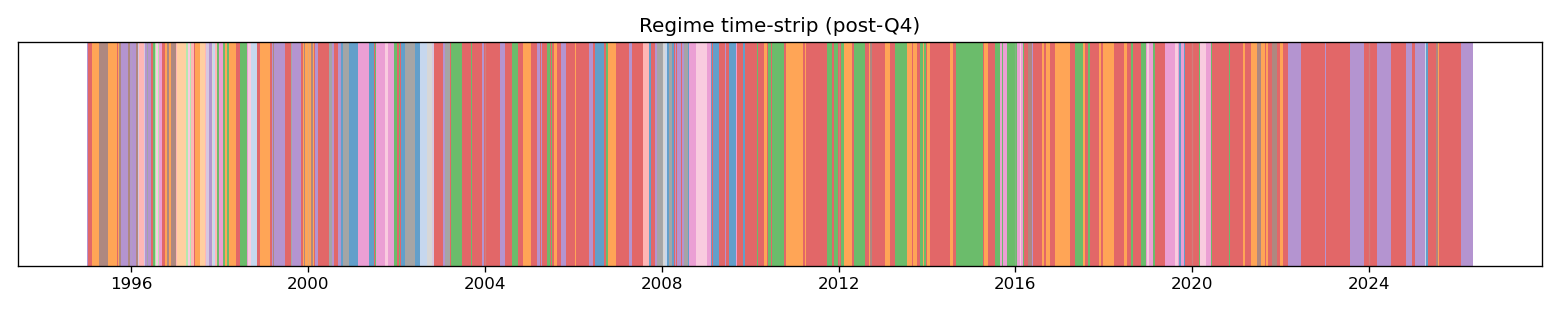

**Conclusion (Q4)**

Both layers now use the same concept-aggregation architecture and live in the same (-1, 1) latent space. Per-axis distributions:

| axis      | layer  | abs_p95 |
|---|---|---:|
| growth    | macro  | 0.77 |
| growth    | market | 0.57 |
| growth    | final  | 0.47 |
| inflation | macro  | 0.60 |
| inflation | market | 0.68 |
| inflation | final  | 0.50 |

**Stress overlay improvements**

Concept aggregation made the risk score more selective — a true crisis now requires *credit AND vol AND flight* to spike together, not just one of them:

| anchor | stress share before (Q3) | stress share after (Q4) | reading |
|---|---:|---:|---|
| 2008 GFC                | 0.68 | **0.67** | held |
| 2020 COVID              | 0.70 | **0.62** | held |
| 2025 Tariff shock       | 0.62 | **0.24** | softened (correct — equity vol but no credit blowout) |
| 2014-16 Oil collapse    | 0.07 | **0.02** | false-positive removed |
| 2018 Q4 Selloff         | 0.49 | **0.08** | false-positive removed (vol spike but credit was fine) |

**Beta-adjusted equity signals** are visibly tighter — the broad_equity_momentum concept has abs_p95 = 0.54 vs 0.7+ for other growth concepts, because beta-adjustment removes systematic moves and leaves only style preference. This is the desired effect.

**Anchors that read correctly**:
- 2008 GFC → Slowdown+Stress 67% ✅
- 2020 COVID → Slowdown+Stress 58% ✅
- 2014-16 Oil collapse → Neutral/Down-Inflation 60% ✅ (inflation correctly disinflationary)
- 2025 Tariff shock → Down-G/Neutral-I+Stress 52% ✅
- 2026 YTD → Neutral/Up-Inflation 80% ✅ (current state)

**Anchors still showing as Neutral/Neutral**: 2009-10 recovery, 2017 soft landing, 2020H2-21 reopening, 2022 inflation, 2023-24 disinflation. These are all macro-vs-market disagreement windows (visible in column 5: 47% in 2009, 24% in 2017, 37% in 2020H2-21, 47% in 2022, 28% in 2023-24). The engine refusing to pick a side is the design.

**Open follow-ups (future rounds)**:
- Dashboard: render per-concept contributions, internal disagreement, and confidence degradation in the HTML report (per the user's dashboard recommendation in Q4 brief).
- Sync the dormant FRED series (T10Y2Y, ICSA, HOUST, …) so they can be activated by adding to a concept block.
- Backtest sanity harness on anchor periods.
- ML layer artifact lifecycle (still disabled).